# Customer Churn & Retention Analysis
**Dataset:** Telco Customer Churn (IBM sample / BlastChar version)

**Goal:** Analyze why customers leave, identify high-risk groups, and convert findings into practical retention recommendations.

Sections: Data Setup → Churn Analysis → Statistical Tests → Segmentation & Revenue at Risk → Findings & Recommendations

## 1. Dataset & Setup

In [42]:
#Import necessary libraries
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import scipy.stats as stats

#Set display options
pd.set_option('display.max_columns', None)

#Set figure size for plots
plt.rcParams['figure.figsize'] = (7,4)

#Read the dataset
df=pd.read_csv('Telco-Customer-Churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [43]:
#Check the shape of the dataset
print("Dataset shape:", df.shape)

Dataset shape: (7043, 21)


In [44]:
#Check the data types and null values in the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [45]:
#Check for missing values in the dataset
print("Missing Values in each column:")
print(df.isnull().sum())

Missing Values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [46]:
#Check for duplicate values in the dataset
print("Duplicate Values in the dataset:", df.duplicated().sum())

Duplicate Values in the dataset: 0


In [47]:
#Check for the descriptive statistics
print("Descriptive Statistics:")
df.describe(include='all')

Descriptive Statistics:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


**Data issue found:** `TotalCharges` is stored as a text (object) column instead of numeric. Converting it to numeric produces missing values for 11 rows — these are new customers with `tenure = 0` (they haven't been billed a full month yet), so the blank is not a data error but a real "no charges yet" case.

**What we changed:**
- Converted `TotalCharges` to numeric with `pd.to_numeric(errors='coerce')`.
- Filled the 11 resulting NaNs with `0`, matching their `tenure = 0` status.
- Mapped `SeniorCitizen` from 0/1 to No/Yes for readability in charts.
- No duplicate rows were found, so no rows were dropped.

In [48]:
#Convert the 'TotalCharges' column to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#Check for missing values in 'TotalCharges' after conversion
print("Missing Values in 'TotalCharges' after conversion:", df['TotalCharges'].isnull().sum())

Missing Values in 'TotalCharges' after conversion: 11


In [49]:
#Shows the customers where TotalCharges is missing, along with their tenure and monthly charges
print(df.loc[df['TotalCharges'].isnull(), ['customerID','tenure','MonthlyCharges', 'TotalCharges']])

      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN


In [50]:
#Fill missing values in 'TotalCharges' with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [51]:
print(df.loc[df['TotalCharges'] == 0, ['customerID','tenure','MonthlyCharges', 'TotalCharges']])

      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           0.0
753   3115-CZMZD       0           20.25           0.0
936   5709-LVOEQ       0           80.85           0.0
1082  4367-NUYAO       0           25.75           0.0
1340  1371-DWPAZ       0           56.05           0.0
3331  7644-OMVMY       0           19.85           0.0
3826  3213-VVOLG       0           25.35           0.0
4380  2520-SGTTA       0           20.00           0.0
5218  2923-ARZLG       0           19.70           0.0
6670  4075-WKNIU       0           73.35           0.0
6754  2775-SEFEE       0           61.90           0.0


In [52]:
#Convert 'SeniorCitizen' column to string type for better analysis
df['SeniorCitizen'] = df['SeniorCitizen'].astype('str')

#Map 'SeniorCitizen' values from 0 and 1 to 'No' and 'Yes'
df['SeniorCitizen']= df['SeniorCitizen'].map({'0':'No','1':'Yes'})

In [53]:
#Creates a new column where Yes → 1 and No → 0, making Churn easier to use in analysis/modeling
df['Churn_flag'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [54]:
df.head()  

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_flag
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## 2. Churn Analysis

### 2.1 Overall churn

In [55]:
#Check the total number of customers in the dataset
Total = len(df)
print("Total customers:", Total)

#Check the total number of churned customers in the dataset
churned = df['Churn_flag'].sum()
print("Total churned customers:", churned)

#Check the total number of retained customers in the dataset
retained = Total - churned
print("Total retained customers:", retained)

#Calculate the churn rate as a percentage of total customers
churn_rate = round(churned / Total * 100, 2)
print("Churn rate:", churn_rate,"%")

Total customers: 7043
Total churned customers: 1869
Total retained customers: 5174
Churn rate: 26.54 %


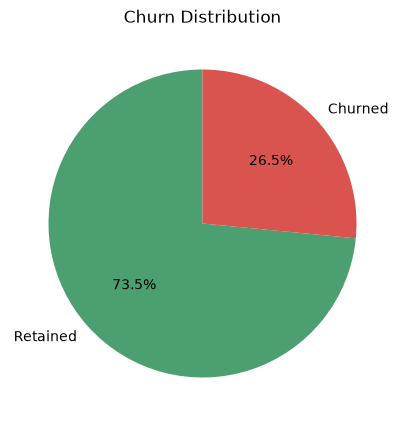

In [56]:
#Visualize the churn distribution using a pie chart
fig, ax = plt.subplots(figsize=(5,5))
ax.pie([retained, churned], labels=['Retained','Churned'], autopct='%1.1f%%', 
       startangle=90, colors=['#4C9F70','#D9534F'])
ax.set_title('Churn Distribution')
plt.show()

**Interpretation:** Roughly 1 in 4 customers (26.5%) has churned, which is a high rate for a subscription-style telecom business and signals a material retention problem worth investigating by segment.

### 2.2 Churn by contract type

In [57]:
#Check the distribution of customers across different contract types
contract_counts = df['Contract'].value_counts()
#Check the churn rate for each contract type
contract_rate = (df.groupby('Contract')["Churn_flag"].mean()*100).round(2)
#Print the counts and churn rates for each contract type in a DataFrame
pd.DataFrame({'Contract Count': contract_counts, 'Churn Rate (%)': contract_rate})


,Contract Count,Churn Rate (%)
Contract,,
Month-to-month,3875,42.71
One year,1473,11.27
Two year,1695,2.83


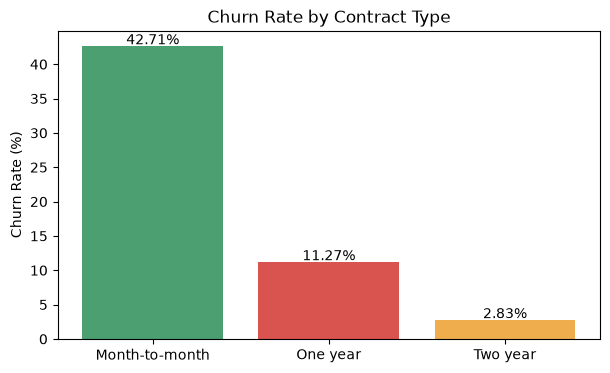

In [58]:
#Plot the distribution of customers across different contract types
fig, ax = plt.subplots()
ax.bar(contract_rate.index, contract_rate.values, color=['#4C9F70','#D9534F','#F0AD4E'])

#Add the churn rate values on top of each bar in the bar chart
for i, v in enumerate(contract_rate.values):
    ax.text(i, v + 0.2, f'{v}%', ha='center')

#Set the title and labels for the bar chart
ax.set_title('Churn Rate by Contract Type')
ax.set_ylabel('Churn Rate (%)')

plt.show()

**Interpretation:** Month-to-month customers churn at 42.7%, roughly 4x the One-year rate (11.3%) and 15x the Two-year rate (2.8%) — contract length is the single strongest lever visible in the data.

### 2.3 Churn by tenure group

In [59]:
#Define tenure range & their labels for categorization
bins = [-1, 12, 24, 48, 100]
labels = ['0-12 months', '13-24 months', '25-48 months', '49+ months']
#Assign the tenure groups to a new column in the DataFrame based on the defined bins and labels
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels)
#Calculates the churn percentage for each tenure group and keeps the specified order of the groups
tenure_rate = (df.groupby('tenure_group')["Churn_flag"].mean()*100).round(2).reindex(labels)
#Counts the number of customers in each tenure group
tenure_counts= df['tenure_group'].value_counts().reindex(labels)
#Print the counts and churn rates for each tenure group in a DataFrame
pd.DataFrame({'Tenure Count': tenure_counts, 'Churn Rate (%)': tenure_rate})


,Tenure Count,Churn Rate (%)
tenure_group,,
0-12 months,2186,47.44
13-24 months,1024,28.71
25-48 months,1594,20.39
49+ months,2239,9.51


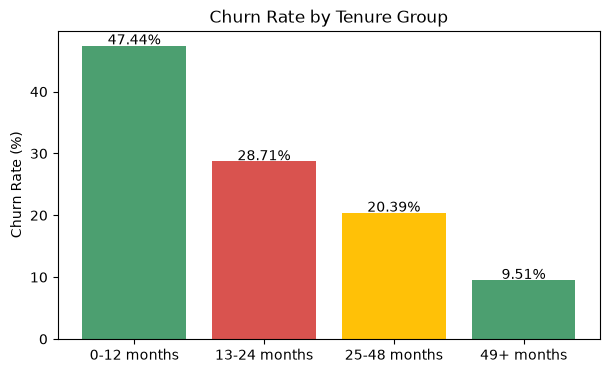

In [60]:
fig, ax = plt.subplots()
ax.bar(tenure_rate.index, tenure_rate.values, color=['#4C9F70','#D9534F','#FFC107'])

for i, v in enumerate(tenure_rate.values):
    ax.text(i, v + 0.2, f'{v}%', ha='center')

ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Tenure Group')
plt.show()


**Interpretation:** Churn falls sharply as tenure increases — 47.4% in the first year vs 9.5% after 4 years — so the first 12 months are the highest-risk, highest-priority window for retention efforts.

### 2.4 Monthly charges: churned vs retained

In [61]:
#Calculate the average monthly charges for churned and retained customers
mc_churned = round(df[df['Churn_flag'] == 1]['MonthlyCharges'].mean(), 2)
mc_retained = round(df[df['Churn_flag'] == 0]['MonthlyCharges'].mean(), 2)
#Print the average monthly charges for churned and retained customers
print("Avg Monthly Charges for Churned Customers:", f"${mc_churned}")
print("Avg Monthly Charges for Retained Customers:", f"${mc_retained}")

Avg Monthly Charges for Churned Customers: $74.44
Avg Monthly Charges for Retained Customers: $61.27


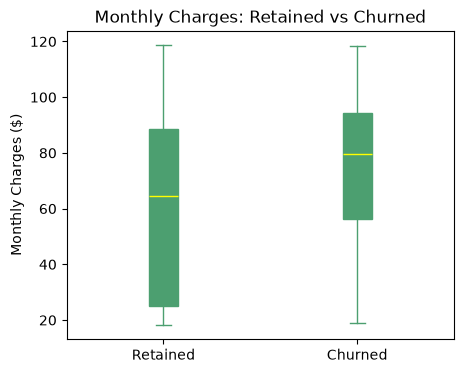

In [62]:
fig, ax = plt.subplots(figsize=(5,4))
ax.boxplot([df[df['Churn_flag'] == 0]['MonthlyCharges'], df[df['Churn_flag'] == 1]['MonthlyCharges']],
           tick_labels=['Retained', 'Churned'], patch_artist=True, boxprops=dict(facecolor='#4C9F70', color='#4C9F70'),
           medianprops=dict(color='yellow'), whiskerprops=dict(color='#4C9F70'), capprops=dict(color='#4C9F70'))
ax.set_title('Monthly Charges: Retained vs Churned')
ax.set_ylabel('Monthly Charges ($)')
plt.show()

**Interpretation:** Churned customers pay $74.44/month on average versus $61.27 for retained customers — customers who leave tend to be on pricier plans, suggesting price sensitivity or a value gap at higher price points.

### 2.5 Churn by payment method

In [63]:
#Check the distribution of customers across different payment methods
pay_rate = round(df.groupby('PaymentMethod')["Churn_flag"].mean()*100, 2).sort_values(ascending=False)
pay_counts = df['PaymentMethod'].value_counts()
#Print the counts and churn rates for each payment method in a DataFrame
pd.DataFrame({'Payment Method Count': pay_counts, 'Churn Rate (%)': pay_rate})

,Payment Method Count,Churn Rate (%)
PaymentMethod,,
Electronic check,2365,45.29
Mailed check,1612,19.11
Bank transfer (automatic),1544,16.71
Credit card (automatic),1522,15.24


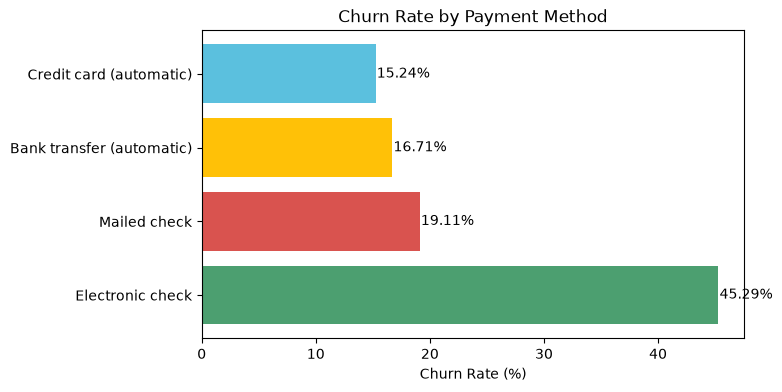

In [64]:
fig, ax = plt.subplots(figsize=(7,4))
ax.barh(pay_rate.index, pay_rate.values, color=['#4C9F70','#D9534F','#FFC107','#5BC0DE','#F0AD4E'])

for i, v in enumerate(pay_rate.values):
    ax.text(v+0.1, i, f'{v}%', va='center')

ax.set_xlabel('Churn Rate (%)')
ax.set_title('Churn Rate by Payment Method')
plt.show()

**Interpretation:** Electronic check has by far the highest churn rate (45.3%), nearly 3x the automatic payment methods (~15-17%) — manual, non-automatic payment is strongly associated with churn, likely because it requires an active monthly decision to stay.

### 2.6 Services: Internet Service & Tech Support

#### Churn Rate by Internet Service

In [65]:
net_rate = round(df.groupby('InternetService')["Churn_flag"].mean()*100, 2).sort_values(ascending=False)
net_counts = df['InternetService'].value_counts()
pd.DataFrame({'Internet Service Count': net_counts, 'Churn Rate (%)': net_rate})

,Internet Service Count,Churn Rate (%)
InternetService,,
Fiber optic,3096,41.89
DSL,2421,18.96
No,1526,7.40


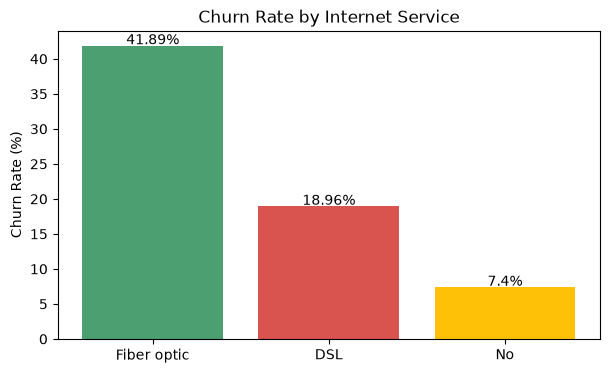

In [66]:
fig, ax = plt.subplots()
ax.bar(net_rate.index, net_rate.values, color=['#4C9F70','#D9534F','#FFC107'])
for i, v in enumerate(net_rate.values):
    ax.text(i, v + 0.2, f'{v}%', ha='center')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Internet Service')
plt.show()

**Interpretation:** Fiber optic customers churn at 41.9% vs 19.0% for DSL and 7.4% for no internet — fiber, despite being the premium product, has the worst retention, which combined with 2.4's price finding suggests fiber pricing/value is a specific pain point.

#### Churn Rate by Online Security

In [67]:
tech_rate = round(df.groupby('TechSupport')["Churn_flag"].mean()*100, 2).sort_values(ascending=False)
tech_counts = df['TechSupport'].value_counts()
pd.DataFrame({'Tech Support Count': tech_counts, 'Churn Rate (%)': tech_rate})

,Tech Support Count,Churn Rate (%)
TechSupport,,
No,3473,41.64
Yes,2044,15.17
No internet service,1526,7.40


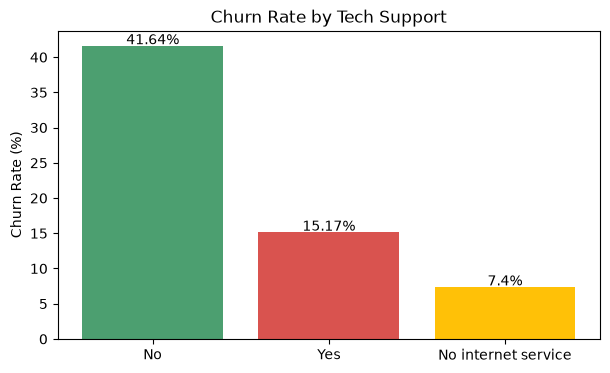

In [68]:
fig, ax = plt.subplots()
ax.bar(tech_rate.index, tech_rate.values, color=['#4C9F70','#D9534F','#FFC107'])
for i, v in enumerate(tech_rate.values):
    ax.text(i, v + 0.2, f'{v}%', ha='center')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Tech Support')
plt.show()

**Interpretation:** Customers without Tech Support churn at 41.6% versus 15.2% for those who have it — Tech Support isn't just a revenue add-on, it appears to function as a retention tool, likely by resolving frustrations before they lead to cancellation.

## 3. Statistical Analysis

### Test 1 — Contract vs Churn (Chi-Square Test of Independence)
- H0: Contract type and churn are independent.
- H1: Contract type and churn are associated.
- α = 0.05

In [69]:
#Creates a contingency table showing the number of customers who churned or stayed for each contract type
contingency_table = pd.crosstab(df['Contract'], df['Churn'], margins=True, margins_name="Total")
contingency_table

Churn,No,Yes,Total
Contract,,,
Month-to-month,2220,1655,3875
One year,1307,166,1473
Two year,1647,48,1695
Total,5174,1869,7043


In [70]:
#Performs a Chi-square test of independence to check whether Contract type and Churn are significantly related
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table.iloc[:-1, :-1])
#Print the test results
print(f"Chi-square Statistic: {chi2: .3f}")
print(f"p-value: {p_value: .3e}")
print(f"Degrees of Freedom: {dof}")

#Makes the statistical decision
Decision = "Reject the null hypothesis (H0)" if p_value < 0.05 else "Fail to reject the null hypothesis"
print(f"Decision: {Decision}")

Chi-square Statistic:  1184.597
p-value:  5.863e-258
Degrees of Freedom: 2
Decision: Reject the null hypothesis (H0)


#### **Interpretation:** 
χ² = 1184.6, p ≈ 5.9e-258, far below α = 0.05, so we reject H0. Contract type and churn are strongly statistically associated — this confirms Section 2.2 is not due to chance. 

Customers with month-to-month contracts have substantially higher churn (1,655 customers) compared with one-year (166) and two-year contracts (48). This indicates that longer-term contracts are strongly associated with customer retention, while month-to-month customers are much more likely to churn

### Test 2 — Monthly Charges vs Churn (Independent Samples T-Test)
- H0: Mean monthly charges are equal for churned and retained customers.
- H1: Mean monthly charges differ between churned and retained customers.
- α = 0.05

In [71]:
#Create the two groups
grp_churned = df[df['Churn_flag'] == 1]['MonthlyCharges']
grp_retained = df[df['Churn_flag'] == 0]['MonthlyCharges']
#Perform the t-test
t_stat, p_val = stats.ttest_ind(grp_churned, grp_retained, equal_var=False)
#Calculate the average monthly charges for churned and retained customers
avg_churned = grp_churned.mean()
avg_retained = grp_retained.mean()
#Print the t-test results
print(f"Avg Monthly Charges - Churned: ${avg_churned: .2f}")
print(f"Avg Monthly Charges - Retained: ${avg_retained: .2f}")  
print(f"T-statistic: {t_stat: .3f}")
print(f"p-value: {p_val: .3e}")

#Make the statistical decision
Decision = "Reject the null hypothesis (H0)" if p_val < 0.05 else "Fail to reject the null hypothesis"
print(f"Decision: {Decision}")


Avg Monthly Charges - Churned: $ 74.44
Avg Monthly Charges - Retained: $ 61.27
T-statistic:  18.408
p-value:  8.592e-73
Decision: Reject the null hypothesis (H0)


#### **Interpretation:** 
The results show that churned customers have a higher average MonthlyCharge ($74.44) compared with retained customers ($61.27). The t-statistic of 18.408 and extremely small p-value of 8.592e-73, which is far below the significance level of α = 0.05, indicate that this difference is statistically significant. Therefore, we reject H₀ and conclude that MonthlyCharges are significantly associated with customer churn. The observed $13.17 price gap is unlikely to be due to random variation alone.

## 4. Customer Segmentation & Revenue at Risk

**Segment rules** (based on tenure and monthly charges only, so churn rate below is a genuine outcome measure, not a tautology):
- **High-Risk**: tenure ≤ 12 months AND monthly charges ≥ $70 (new *and* expensive — least locked-in, most price-exposed)
- **New**: tenure ≤ 12 months, monthly charges < $70
- **High-Value**: tenure > 12 months, monthly charges ≥ $70
- **Loyal**: tenure > 12 months, monthly charges < $70

In [72]:
# Define the segmentation function
def segment(row):
    new = row['tenure'] <= 12
    high_charge = row['MonthlyCharges'] >= 70
    # Assign the segment
    if new and high_charge:
        return 'High_risk'
    elif new:
        return 'New'
    elif high_charge:
        return 'High_value'
    else:
        return 'Loyal'

# Apply the segmentation function to create a new column 'Segment'
df['Segment'] = df.apply(segment, axis=1)

#Create segment summary table showing the number of customers and churn rate for each segment
segment_summary = df.groupby('Segment').agg(
    Customer_Count=('customerID', 'count'),
    avg_Tenure=('tenure', 'mean'),
    avg_MonthlyCharges=('MonthlyCharges', 'mean'),
    Churn_Rate=('Churn_flag', 'mean')
).reset_index()

#Round the values in the segment summary table for better readability
segment_summary['avg_Tenure'] = segment_summary['avg_Tenure'].round(2)
segment_summary['avg_MonthlyCharges'] = segment_summary['avg_MonthlyCharges'].round(2)

#Convert the churn rate to percentage format
segment_summary['Churn_Rate_%'] = (segment_summary['Churn_Rate'] * 100).round(2)

#Remove the original churn rate
segment_summary = segment_summary.drop(columns='Churn_Rate').sort_values('Churn_Rate_%', ascending=False)

print(segment_summary)



      Segment  Customer_Count  avg_Tenure  avg_MonthlyCharges  Churn_Rate_%
0   High_risk             880        5.07               83.00         68.07
3         New            1306        4.50               37.97         33.54
1  High_value            2711       47.04               92.52         24.90
2       Loyal            2146       42.00               38.52          7.32


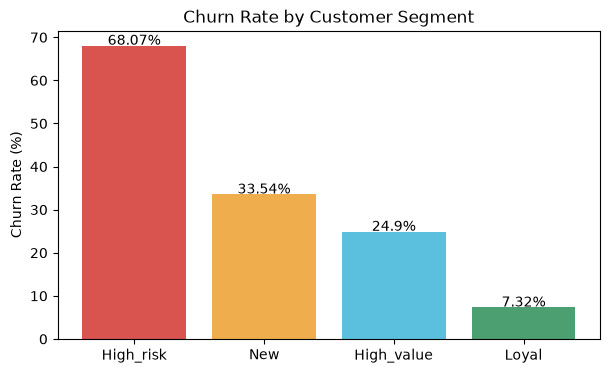

In [73]:
fig, ax = plt.subplots()
ax.bar(segment_summary['Segment'], segment_summary['Churn_Rate_%'], color=['#D9534F','#F0AD4E','#5BC0DE','#4C9F70'])
for i, v in enumerate(segment_summary['Churn_Rate_%']):
    ax.text(i, v + 0.2, f'{v}%', ha='center')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Customer Segment')
plt.show()

**Which segment needs the most retention attention?**

**High-Risk** requires the most retention attention, with 880 customers and a 68.1% churn rate. These customers are relatively new (5.1 months average tenure) but already pay high monthly charges ($83/month). This combination of low tenure and high cost makes them the most vulnerable to churn, with a churn rate nearly 3× the overall rate.

In [74]:
#Calculate Monthly Revenue at Risk = sum of MonthlyCharges for churned customers
revenue_at_risk = df[df['Churn_flag'] == 1]['MonthlyCharges'].sum()
print (f"Monthly Revenue at Risk due to Churn: ${revenue_at_risk:,.2f}")

Monthly Revenue at Risk due to Churn: $139,130.85


#### **Interpretation**
The 1,869 churned customers represent approximately $139K in monthly recurring revenue at risk, equivalent to about $1.67M annually if those customers had remained and their monthly charges stayed unchanged.

## 5. Power BI Dashboard

In [75]:
df.to_csv('Telco-Customer-Churn-Cleaned.csv', index=False)
print('Exported cleaned dataset to Telco-Customer-Churn-Cleaned.csv for Power BI dashboard')

Exported cleaned dataset to Telco-Customer-Churn-Cleaned.csv for Power BI dashboard


## 6. Findings & Recommendations

### Key Findings

1. **Overall churn is 26.5%** (1,869 of 7,043 customers), indicating a significant retention challenge.

2. **Contract type is the strongest churn factor:** Month-to-month customers churn at **42.7%**, compared with **11.3%** for One-year and **2.8%** for Two-year contracts. The relationship is statistically significant (**χ² p < 0.001**).

3. **New customers are the highest-risk group:** churn is **47.4%** within the first 12 months, dropping to **9.5%** among customers with 48+ months of tenure.

4. **Higher monthly charges are associated with churn:** churned customers pay an average of **$74.44/month** versus **$61.27** for retained customers (**t-test p < 0.001**). Fiber optic customers also have higher churn (**41.9%**) than DSL customers (**19.0%**).

5. **Payment method and support matter:** Electronic check customers have a **45.3% churn rate**, compared with roughly **15–17%** for automatic payment methods. Customers without Tech Support churn at **41.6%**, versus **15.2%** among customers with support.

### Recommendations

1. **Incentivize longer-term contracts** by offering discounts or additional benefits to Month-to-month customers who switch to One- or Two-year plans.

2. **Strengthen first-year onboarding** with proactive check-ins and engagement campaigns for customers in their first 12 months.

3. **Review Fiber optic pricing and value**, considering bundled benefits, loyalty pricing, or service enhancements to reduce price-related churn.

4. **Encourage automatic payments** among Electronic check users through small incentives, reminders, or simplified enrollment.

5. **Promote Tech Support proactively**, particularly among new and Fiber customers. Prioritize the **880 High-Risk customers**, who have the highest segment churn rate at **68.1%**.

## Overall Strategy

Focus first on **High-Risk new customers**, then address the major behavioral levers — **contract length, pricing/value, payment method, and support availability**.